# Bernoulli Equation – Supervised Learning Regression

This notebook applies **Ridge Regression** and **Support Vector Regression (SVR)** to predict the **total pressure** of a fluid (water or air) governed by the Bernoulli equation:

$$P_{\text{tot}} = \underbrace{p}_{\text{static}} + \underbrace{\frac{1}{2}\rho v^2}_{\text{dynamic}} + \underbrace{\rho g h}_{\text{hydrostatic}}$$

Two feature sets are compared:
- **Standard Features (SFs):** raw physical quantities (ρ, v, Q, A, μ, h, p)
- **Physics-Informed Features (SPIFs):** derived pressure terms (p_static, p_dynamic, p_hydrostatic, and nonlinear combinations)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.svm import SVR, LinearSVR
import matplotlib.pyplot as plt

## 2. Synthetic Dataset Generation

8000 samples are generated for two fluids (water and air) with physically realistic ranges:
- **Density** ρ: 1000 kg/m³ (water) or 1.225 kg/m³ (air)
- **Pressure** p: 1 kPa–10 MPa (water) or 100 Pa–100 kPa (air)

Total pressure is computed from the Bernoulli equation and Gaussian noise is added to simulate measurement uncertainty.

14993364.563833075
324.2515431915964
14993040.312289882


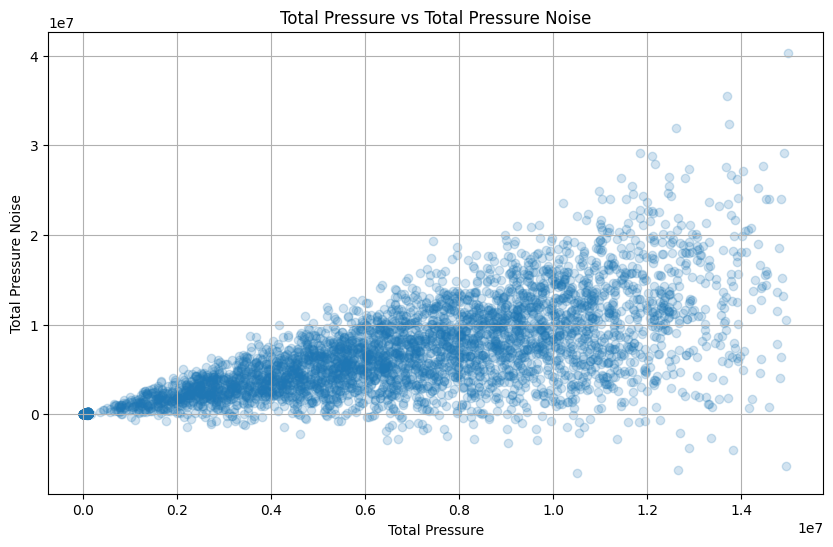

In [2]:
np.random.seed(42)

# --- Fluid properties ---
# Density (kg/m³): water = 1000, air = 1.225
rho_water = 1000
rho_air = 1.225
fluid_type = np.random.choice(['water', 'air'], size=8000)
rho = np.where(fluid_type == 'water', rho_water, rho_air)

# Velocity (m/s): uniform in [0.01, 100]
v = np.random.uniform(0.01, 100, 8000)

# Volumetric flow rate (m³/s): uniform in [0.001, 10]
Q = np.random.uniform(0.001, 10, 8000)

# Cross-sectional area (m²): uniform in [0.01, 5]
A = np.random.uniform(0.01, 5, 8000)

# Dynamic viscosity (Pa·s): water ≈ 0.001, air ≈ 1.8e-5
mi_water = 0.001
mi_air = 0.000018
mi = np.where(fluid_type == 'water', mi_water, mi_air)

# Gravitational acceleration (m/s²)
g = 9.81

# Height (m): uniform in [0.01, 100]
h = np.random.uniform(0.01, 100, 8000)

# --- Pressure components ---
# Hydrostatic pressure: P_hyd = ρ g h
hydro_p = rho * g * h

# Dynamic pressure: P_dyn = ρ v²
dynamic_p = rho * v**2

# Static pressure: fluid-specific ranges
#   water: 1 kPa – 10 MPa | air: 100 Pa – 100 kPa
water_p = np.random.uniform(1e3, 1e7, 8000)
air_p   = np.random.uniform(100, 1e5, 8000)
p = np.where(fluid_type == 'water', water_p, air_p)

# --- Bernoulli total pressure: P_tot = p + 0.5 ρ v² + ρ g h ---
total_p = p + 0.5 * dynamic_p + hydro_p

total_p_range = total_p.max() - total_p.min()

# Add Gaussian noise with amplitude proportional to |P_tot| 
noise = np.random.normal(0, 0.5 * np.abs(total_p), size=total_p.shape)
total_p_noise = total_p + noise

# Print dataset statistics
print(total_p.max())
print(total_p.min())
print(total_p_range)

# Scatter plot: clean vs noisy total pressure
plt.figure(figsize=(10, 6))
plt.scatter(total_p, total_p_noise, alpha=0.2)
plt.title('Total Pressure vs Total Pressure Noise')
plt.xlabel('Total Pressure')
plt.ylabel('Total Pressure Noise')
plt.grid(True)
plt.show()


## 3. Standard Features (SFs) – Preprocessing

Features: ρ, v, Q, A, μ, h, p (raw physical quantities).  
Target: noisy total pressure.  
Data is split 80/20 and standardized with `StandardScaler` (zero mean, unit variance).

In [3]:
# --- Build dataframe with standard (raw) features ---
data_feat = {
    'Density (kg/m³)': rho,
    'Velocity (m/s)': v,
    'Volume Flow Rate (m³/s)': Q,
    'Area (m²)': A,
    'Viscosity (Pa·s)': mi,
    'Height (m)': h,
    'Pressure (Pa)': p,
    'Total Pressure (Pa)': total_p_noise,
}

df_feat = pd.DataFrame(data_feat)
print(df_feat)

# Separate features (X) and target (Y)
X_feat = df_feat.drop(columns=['Total Pressure (Pa)'])
Y_feat = df_feat['Total Pressure (Pa)']

# 80/20 train-test split
X_train_feat, X_test_feat, Y_train_feat, Y_test_feat = train_test_split(
    X_feat, Y_feat, test_size=0.2, random_state=42
)

# Standardize features and target independently (zero mean, unit variance)
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_feat_scaled = scaler_X.fit_transform(X_train_feat)
Y_train_feat_scaled = scaler_Y.fit_transform(Y_train_feat.values.reshape(-1, 1)).flatten()
X_test_feat_scaled  = scaler_X.transform(X_test_feat)
Y_test_feat_scaled  = scaler_Y.transform(Y_test_feat.values.reshape(-1, 1)).flatten()

print(f"TRAIN: {X_train_feat_scaled}, {Y_train_feat_scaled}")
print(f"TEST: {X_test_feat_scaled}, {Y_test_feat_scaled}")


      Density (kg/m³)  Velocity (m/s)  Volume Flow Rate (m³/s)  Area (m²)  \
0            1000.000       57.203868                 6.543409   3.652692   
1               1.225       80.545179                 0.801246   0.930715   
2            1000.000       76.018491                 2.424056   1.739732   
3            1000.000       15.398451                 7.737020   3.319770   
4            1000.000       14.933454                 5.287330   2.415626   
...               ...             ...                      ...        ...   
7995         1000.000        0.474402                 8.770509   1.087781   
7996            1.225       87.368129                 0.469093   4.053095   
7997            1.225       30.739445                 3.037681   1.421530   
7998         1000.000       93.859500                 4.433757   0.182104   
7999         1000.000       31.701359                 1.723476   0.558574   

      Viscosity (Pa·s)  Height (m)  Pressure (Pa)  Total Pressure (Pa)  
0 

### 3.1 Ridge Regression on SFs

5-fold cross-validated `GridSearchCV` selects the best regularization parameter α from {0.001, 0.01, 0.1, 1, 10}.  
Coefficients are back-transformed to the original (unstandardized) domain.

In [4]:
# --- Ridge Regression on Standard Features ---
# fit_intercept=True includes a bias term in the model
ridge = Ridge(fit_intercept=True)

# Candidate regularization strengths (α): larger α → stronger shrinkage
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# 5-fold CV, scored by negative MAE
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_feat_scaled, Y_train_feat_scaled)

best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Evaluate on test set
best_model   = grid_search.best_estimator_
Y_pred_feat  = best_model.predict(X_test_feat_scaled)

mae1 = mean_absolute_error(Y_test_feat_scaled, Y_pred_feat)
mse1 = mean_squared_error(Y_test_feat_scaled, Y_pred_feat)
print(f"MAE test: ", mae1)
print(f"MSE test: ", mse1)

# Normalized relative error: n * MSE / ||y||²
err_rel = np.shape(Y_test_feat_scaled)[0] * mse1 / (np.linalg.norm(Y_test_feat_scaled)**2)
print('norm', np.linalg.norm(Y_test_feat_scaled))
print(f"Relative error new: {err_rel}")

print(f"Coefficients (weights): {best_model.coef_}")

intercept = best_model.intercept_
print(f"Intercept: {intercept}")

# Back-transform coefficients to the original (unstandardized) domain.
# For StandardScaler: β_orig = β_scaled * σ_y / σ_x
# Reference: https://stats.stackexchange.com/questions/393581
stdev_y = np.std(Y_train_feat, ddof=1)   # sample std of target
stdev_X = np.std(X_train_feat, axis=0, ddof=1)  # sample std of each feature
original_coefs = (best_model.coef_ * stdev_y) / stdev_X

print(f"Original coefficients (weights): {original_coefs}")
print(f"stdev_y: {stdev_y}")
print(f"stdev_X: {stdev_X}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: 10.0
MAE test:  0.35352465436298175
MSE test:  0.3301077725755243
norm 40.24670330789281
Relative error new: 0.32607320217254
Coefficients (weights): [ 0.10661367  0.14533097 -0.00403921  0.00105644  0.10661367  0.03049168
  0.62596606]
Intercept: 7.288275791454125e-18
Original coefficients (weights): Density (kg/m³)            1.088105e+03
Velocity (m/s)             2.571094e+04
Volume Flow Rate (m³/s)   -7.120790e+03
Area (m²)                  3.744488e+03
Viscosity (Pa·s)           1.106692e+09
Height (m)                 5.408661e+03
Pressure (Pa)              9.883785e-01
dtype: float64
stdev_y: 5097029.347388766
stdev_X: Density (kg/m³)            4.994125e+02
Velocity (m/s)             2.881094e+01
Volume Flow Rate (m³/s)    2.891251e+00
Area (m²)                  1.438042e+00
Viscosity (Pa·s)           4.910246e-04
Height (m)                 2.873483e+01
Pressure (Pa)              3.228083e+06
dtype: float64

### 3.2 SVR (Linear Kernel) on SFs

A `SVR` with linear kernel is tuned via `GridSearchCV` (C=0.1).  
Primal coefficients are recovered from dual variables: `w = dual_coef_ @ support_vectors_`.

In [5]:
# --- SVR (linear kernel) on Standard Features ---
svr = SVR()

param_grid = {
    'C': [0.1],
    'kernel': ['linear'],
}

grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_feat_scaled, Y_train_feat_scaled)

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

best_model  = grid_search.best_estimator_
Y_pred_feat = best_model.predict(X_test_feat_scaled)

mae1 = mean_absolute_error(Y_test_feat_scaled, Y_pred_feat)
mse1 = mean_squared_error(Y_test_feat_scaled, Y_pred_feat)
print("MAE test:", mae1)
print("MSE test:", mse1)

err_rel = np.shape(Y_test_feat_scaled)[0] * mse1 / (np.linalg.norm(Y_test_feat_scaled)**2)
print('norm', np.linalg.norm(Y_test_feat_scaled))
print(f"Relative error new: {err_rel}")

# Recover primal coefficients from dual representation:
# w = Σ α_i y_i x_i  →  dual_coef_ @ support_vectors_
coef_scaled      = np.dot(best_model.dual_coef_, best_model.support_vectors_).flatten()
intercept_scaled = best_model.intercept_[0]

# Back-transform to original domain
stdev_y = np.std(Y_train_feat, ddof=1)
stdev_X = np.std(X_train_feat, axis=0, ddof=1)
coef_original      = coef_scaled * stdev_y / stdev_X
intercept_original = Y_train_feat.mean() - np.sum(coef_original * X_train_feat.mean(axis=0))

print("Coefficients (original domain):", coef_original)
print("Intercept (original domain):", intercept_original)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'C': 0.1, 'kernel': 'linear'}
MAE test: 0.3293134777270088
MSE test: 0.33792926787406735
norm 40.24670330789281
Relative error new: 0.33379910331650625
Coefficients (original domain): Density (kg/m³)            9.047644e+02
Velocity (m/s)             1.244265e+04
Volume Flow Rate (m³/s)   -3.753549e+03
Area (m²)                  3.823997e+03
Viscosity (Pa·s)           9.202200e+08
Height (m)                 1.705376e+03
Pressure (Pa)              1.018124e+00
dtype: float64
Intercept (original domain): -598090.3573737969


## 4. Physics-Informed Features (SPIFs) – Preprocessing

Features are derived pressure quantities that encode physical knowledge:

| Label | Expression | Physical meaning |
|-------|-----------|------------------|
| p_static | p | Static pressure |
| p_dynamic | ρ v² | Dynamic pressure |
| p_hydrostatic | ρ g h | Hydrostatic pressure |
| P1 | p Q / (A v) | Pressure × flow/velocity ratio |
| P2 | μ v / h | Viscous-velocity term |
| P3 | μ Q / (h A²) | Viscous-flow term |
| P4 | ρ g A / h | Gravitational-geometric term |

Target: noisy total pressure. Standardized with `StandardScaler`.

In [6]:
# --- Build dataframe with Physics-Informed Features (SPIFs) ---
# Each feature is a pressure-like quantity derived from the raw variables
data_op = {
    'Pressure (Pa)':            p,
    'Dynamic Pressure (Pa)':    dynamic_p,          # ρ v²
    'Hydrostatic Pressure (Pa)': hydro_p,            # ρ g h
    'P1 (Pa)':                  p * Q / (A * v),    # static pressure × flow/velocity ratio
    'P2 (Pa)':                  mi * v / h,          # viscous-velocity term
    'P3 (Pa)':                  mi * Q / (h * A**2), # viscous-flow term
    'P4 (Pa)':                  rho * g * A / h,     # gravitational-geometric term
    'Total Pressure (Pa)':      total_p_noise,
}

df_op = pd.DataFrame(data_op)
print(df_op.head())

# Separate features (X) and target (Y)
X_op = df_op.drop(columns=['Total Pressure (Pa)'])
Y_op = df_op['Total Pressure (Pa)']

# 80/20 train-test split
X_train_op, X_test_op, Y_train_op, Y_test_op = train_test_split(
    X_op, Y_op, test_size=0.2, random_state=42
)

# Standardize features and target independently
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_op_scaled = scaler_X.fit_transform(X_train_op)
Y_train_op_scaled = scaler_Y.fit_transform(Y_train_op.values.reshape(-1, 1)).flatten()
X_test_op_scaled  = scaler_X.transform(X_test_op)
Y_test_op_scaled  = scaler_Y.transform(Y_test_op.values.reshape(-1, 1)).flatten()

print(f"TRAIN: {X_train_op_scaled}, {Y_train_op_scaled}")
print(f"TEST: {X_test_op_scaled}, {Y_test_op_scaled}")


   Pressure (Pa)  Dynamic Pressure (Pa)  Hydrostatic Pressure (Pa)  \
0   9.166007e+06           3.272282e+06              731732.763176   
1   8.877093e+04           7.947219e+03                 315.025863   
2   4.509693e+04           5.778811e+06              641750.754306   
3   3.171433e+06           2.371123e+05              685943.632192   
4   8.373943e+06           2.230081e+05              338625.457489   

        P1 (Pa)   P2 (Pa)       P3 (Pa)     P4 (Pa)  Total Pressure (Pa)  
0  2.870423e+05  0.000767  6.574982e-06  480.395042         4.498704e+06  
1  9.488122e+02  0.000055  6.351317e-07    0.426659         1.291227e+05  
2  8.265859e+02  0.001162  1.224279e-05  260.887936         7.498703e+06  
3  4.800033e+05  0.000220  1.004010e-05  465.755113         5.056267e+06  
4  1.227373e+06  0.000433  2.624983e-05  686.511908         7.773927e+06  
TRAIN: [[-0.78441575 -0.61596253 -0.77359162 ... -0.03435546 -0.02101378
  -0.06344586]
 [-0.79257996 -0.61488599 -0.77351152 ...

### 4.1 Ridge Regression on SPIFs

Features are added incrementally in descending order of |coefficient| to detect the saturation point where additional features no longer improve MAE/MSE.  
This identifies the minimal set of SPIFs needed for accurate prediction.

In [7]:
# --- Ridge Regression on Physics-Informed Features (SPIFs) ---
ridge = Ridge(fit_intercept=True)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_op_scaled, Y_train_op_scaled)

best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

best_model = grid_search.best_estimator_
Y_pred_op  = best_model.predict(X_test_op_scaled)

mae1 = mean_absolute_error(Y_test_op_scaled, Y_pred_op)
mse1 = mean_squared_error(Y_test_op_scaled, Y_pred_op)
print(f"MAE test: ", mae1)
print(f"MSE test: ", mse1)

err_rel = np.shape(Y_test_op_scaled)[0] * mse1 / (np.linalg.norm(Y_test_op_scaled)**2)
print('norm', np.linalg.norm(Y_test_op_scaled))
print(f"Relative error new: {err_rel}")

print(f"Coefficients (weights): {best_model.coef_}")

# --- Incremental feature importance analysis ---
# Sort features by descending |coefficient| and add them one by one,
# tracking how MAE and MSE evolve to identify the saturation point.
feature_names   = X_op.columns
sorted_indices  = np.argsort(np.abs(best_model.coef_))[::-1]  # descending |coef|
sorted_feature_names = feature_names[sorted_indices]

# MAE accumulation
mae_list      = []
added_features = []

Y_cumulative = X_test_op_scaled[:, sorted_indices[0]] * best_model.coef_[sorted_indices[0]]
mae = mean_absolute_error(Y_test_op_scaled, Y_cumulative)
mae_list.append(mae)
added_features.append(sorted_feature_names[0])
for i in range(1, len(best_model.coef_)):
    Y_cumulative += X_test_op_scaled[:, sorted_indices[i]] * best_model.coef_[sorted_indices[i]]
    mae = mean_absolute_error(Y_test_op_scaled, Y_cumulative)
    mae_list.append(mae)
    added_features.append(sorted_feature_names[i])
for idx, (mae, feature) in enumerate(zip(mae_list, added_features)):
    print(f"MAE after adding feature '{feature}' ({idx+1}): {mae}")

# MSE accumulation
mse_list      = []
added_features = []
Y_cumulative = X_test_op_scaled[:, sorted_indices[0]] * best_model.coef_[sorted_indices[0]]
mse = mean_squared_error(Y_test_op_scaled, Y_cumulative)
mse_list.append(mse)
added_features.append(sorted_feature_names[0])
for i in range(1, len(best_model.coef_)):
    Y_cumulative += X_test_op_scaled[:, sorted_indices[i]] * best_model.coef_[sorted_indices[i]]
    mse = mean_squared_error(Y_test_op_scaled, Y_cumulative)
    mse_list.append(mse)
    added_features.append(sorted_feature_names[i])
for idx, (mse, feature) in enumerate(zip(mse_list, added_features)):
    print(f"MSE after adding feature '{feature}' ({idx+1}): {mse}")

intercept = best_model.intercept_
print(f"Intercept: {intercept}")

# Back-transform coefficients to original domain
# Reference: https://stats.stackexchange.com/questions/393581
stdev_y = np.std(Y_train_op, ddof=1)
stdev_X = np.std(X_train_op, axis=0, ddof=1)
original_coefs = (best_model.coef_ * stdev_y) / stdev_X

print(f"Original coefficients (weights): {original_coefs}")
print(f"stdev_y: {stdev_y}")
print(f"stdev_X: {stdev_X}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: 10.0
MAE test:  0.2813911628206192
MSE test:  0.3009819141962641
norm 40.24670330789281
Relative error new: 0.29730331943499716
Coefficients (weights): [ 0.62725276  0.26418287  0.06305715  0.00801519  0.00273593 -0.00411356
  0.00691149]
MAE after adding feature 'Pressure (Pa)' (1): 0.4244512681670624
MAE after adding feature 'Dynamic Pressure (Pa)' (2): 0.30633655758100364
MAE after adding feature 'Hydrostatic Pressure (Pa)' (3): 0.2816526980942086
MAE after adding feature 'P1 (Pa)' (4): 0.2814548959184788
MAE after adding feature 'P4 (Pa)' (5): 0.28138126657683804
MAE after adding feature 'P3 (Pa)' (6): 0.2814057977023483
MAE after adding feature 'P2 (Pa)' (7): 0.2813911628206192
MSE after adding feature 'Pressure (Pa)' (1): 0.40159290030572187
MSE after adding feature 'Dynamic Pressure (Pa)' (2): 0.3037840322271155
MSE after adding feature 'Hydrostatic Pressure (Pa)' (3): 0.30125348344021063
MSE after adding fe

#### MAE & MSE Saturation – Ridge Regression

Plot MAE and MSE as each SPIF is added (sorted by importance). The vertical dashed line marks the saturation point beyond which additional features are redundant.

7
7


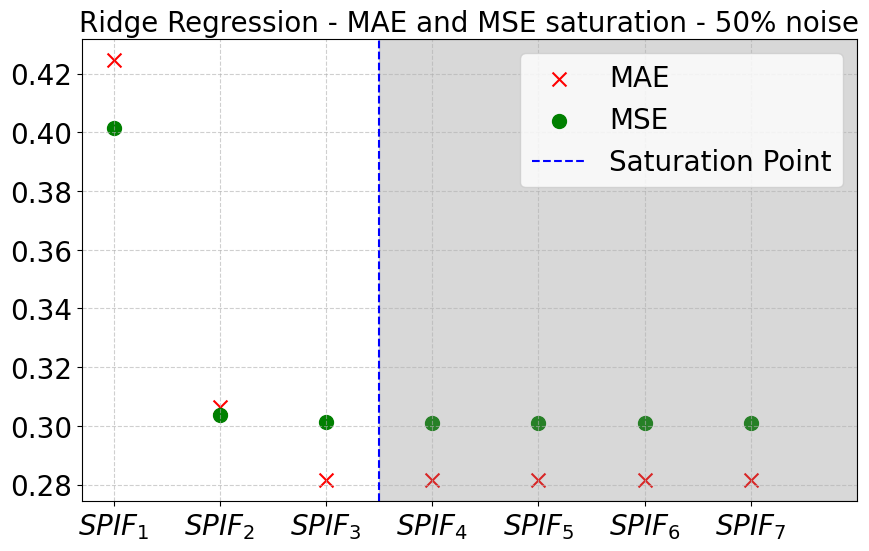

In [8]:
num_features = len(added_features)
print(num_features)
print(len(mae_list))

# LaTeX-style labels for x-axis ticks: SPIF_1, SPIF_2, ...
feature_labels = [f"$SPIF_{{{i+1}}}$" for i in range(num_features)]

plt.figure(figsize=(10, 6))
plt.scatter(feature_labels, mae_list, marker='x', color='r', s=100, label='MAE')
plt.scatter(feature_labels, mse_list, marker='o', color='g', s=100, label='MSE')

# Shade the saturation region (features beyond the saturation point contribute negligibly)
if num_features > 3:
    plt.axvline(x=2.5, color='b', linestyle='--', label='Saturation Point')
    x_lim = plt.xlim(right=7)
    plt.axvspan(2.5, x_lim[1], color='gray', alpha=0.3)

plt.title('Ridge Regression - MAE and MSE saturation - 50% noise', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=20)
plt.show()


#### Absolute Error Distribution – Ridge Regression

Boxplot of absolute errors comparing SPIFs vs SFs (outliers removed via IQR filter).  
Mean (red dot) and median (blue bar) are shown explicitly.

Absolute Errors PIFs (filtered): [0.0020666564536612198, 0.00438848870138786, 0.004017224970147781, 0.4226801785350368, 0.1874188204837638, 0.0020712401710534234, 0.08415292181731737, 0.00836937379128122, 0.0020055687613891315, 0.0018682130444072076, 0.0013001868972383201, 0.436174392745452, 0.0005119959696696652, 0.007846061610416566, 0.001620017311981914, 0.0012430941034037302, 0.6781609040878094, 0.0032194690759113076, 0.029414370760928565, 0.006074672010670801, 0.0008001210306157747, 0.1741899687365478, 0.0037495506179394678, 0.150977306034845, 0.28674450947049085, 0.26227690015497057, 0.15844476507969718, 0.0007039974237630364, 0.2975852495334529, 0.9946134068057664, 0.0009622409744249882, 0.013079064219884695, 0.007374488106908772, 0.5690335834606621, 0.6001322039850288, 0.00878373325112991, 0.9065377686673244, 0.0027785330152712007, 0.0015147263290460344, 0.000566767109200006, 0.0019340358040972339, 0.001005887493334745, 0.0035727699378685918, 0.2925295896331068, 0.1909800005548

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_23051/2540302963.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)


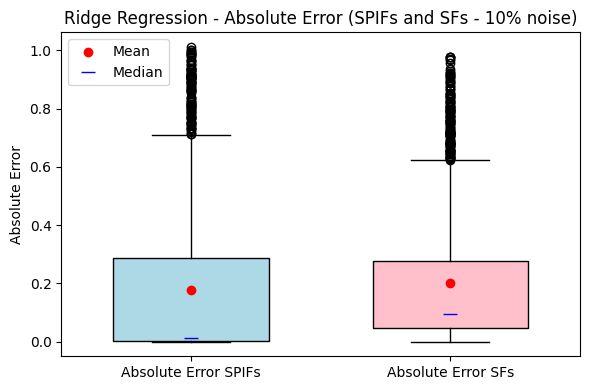

In [9]:
# --- Absolute error comparison: SPIFs vs SFs (Ridge Regression) ---
absolute_errors_op = []
for true_value, predicted_value in zip(Y_test_op_scaled, Y_pred_op):
    error = abs(true_value - predicted_value)
    absolute_errors_op.append(error)

absolute_errors_feat = []
for true_value, predicted_value in zip(Y_test_feat_scaled, Y_pred_feat):
    error = abs(true_value - predicted_value)
    absolute_errors_feat.append(error)

# Remove outliers using the IQR rule: discard values outside [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

absolute_errors_op   = remove_outliers(absolute_errors_op)
absolute_errors_feat = remove_outliers(absolute_errors_feat)

print("Absolute Errors PIFs (filtered):", absolute_errors_op)
print("Absolute Errors SFs (filtered):", absolute_errors_feat)

colors = {'op': 'lightblue', 'feat': 'pink'}

def create_boxplot(data, labels, title):
    plt.figure(figsize=(6, 4))
    # patch_artist fills boxes with color; default median line is hidden
    box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)

    for patch, label in zip(box['boxes'], labels):
        if 'SPIFs' in label:
            patch.set_facecolor(colors['op'])
        else:
            patch.set_facecolor(colors['feat'])

    # Hide default median line; redraw mean and median as explicit markers
    for median in box['medians']:
        median.set_visible(False)

    means   = [np.mean(d) for d in data]
    medians = [np.median(d) for d in data]

    plt.scatter(range(1, len(labels) + 1), means,   marker='o', color='red',  zorder=3, label='Mean')
    plt.plot(   range(1, len(labels) + 1), medians, marker='_', color='blue', markersize=10,
                linestyle='None', zorder=4, label='Median')

    plt.title(title)
    plt.ylabel('Absolute Error')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

data   = [absolute_errors_op, absolute_errors_feat]
labels = ['Absolute Error SPIFs', 'Absolute Error SFs']

create_boxplot(data, labels, 'Ridge Regression - Absolute Error (SPIFs and SFs - 10% noise)')


#### Squared Error Distribution – Ridge Regression

Squared Errors SPIFs (filtered): [4.271068897459569e-06, 1.925883308220891e-05, 1.6138096460778842e-05, 0.1786585333264106, 0.03512581427152528, 4.290035846185415e-06, 0.00708171425039153, 7.004641765818499e-05, 4.022306056659936e-06, 3.490219979293247e-06, 1.69048596775021e-06, 0.1902481008868638, 2.621398729579807e-07, 6.15606827944526e-05, 2.624456091121106e-06, 1.5452829499171238e-06, 1.0364981130749208e-05, 0.0008652052072613693, 3.690164003722723e-05, 6.401936636336494e-07, 0.0303421452084395, 1.4059129836490245e-05, 0.022794146937539242, 0.08222241371147242, 0.0687891723549004, 0.025104743581160428, 4.956123726649923e-07, 0.08855698073988742, 9.259076928623509e-07, 0.00017106192086786804, 5.4383074838938924e-05, 0.32379921910608234, 0.36015866225992815, 7.715396982700523e-05, 7.72024571695207e-06, 2.2943958519052752e-06, 3.212249560709315e-07, 3.740494491530034e-06, 1.0118096492472567e-06, 1.2764685028937541e-05, 0.08557356081091388, 0.03647336061193288, 3.1519692000168233e-07, 

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_23051/1582566034.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)


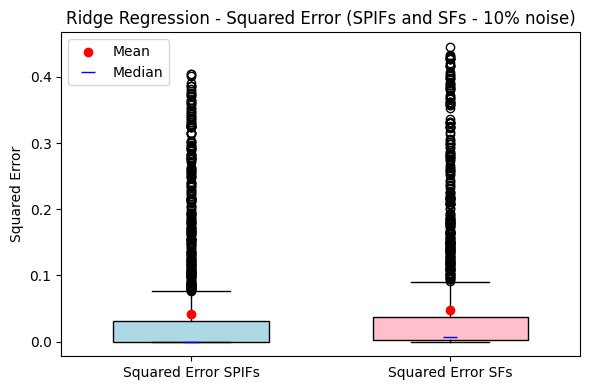

In [10]:
# --- Squared error comparison: SPIFs vs SFs (Ridge Regression) ---
squared_errors_op = []
for true_value, predicted_value in zip(Y_test_op_scaled, Y_pred_op):
    error = (true_value - predicted_value)**2
    squared_errors_op.append(error)

squared_errors_feat = []
for true_value, predicted_value in zip(Y_test_feat_scaled, Y_pred_feat):
    error = (true_value - predicted_value)**2
    squared_errors_feat.append(error)

# Remove outliers using the IQR rule
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

squared_errors_op   = remove_outliers(squared_errors_op)
squared_errors_feat = remove_outliers(squared_errors_feat)

print("Squared Errors SPIFs (filtered):", squared_errors_op)
print("Squared Errors SFs (filtered):", squared_errors_feat)

colors = {'op': 'lightblue', 'feat': 'pink'}

def create_boxplot(data, labels, title):
    plt.figure(figsize=(6, 4))
    box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)

    for patch, label in zip(box['boxes'], labels):
        if 'PIFs' in label:
            patch.set_facecolor(colors['op'])
        else:
            patch.set_facecolor(colors['feat'])

    for median in box['medians']:
        median.set_visible(False)

    means   = [np.mean(d) for d in data]
    medians = [np.median(d) for d in data]

    plt.scatter(range(1, len(labels) + 1), means,   marker='o', color='red',  zorder=3, label='Mean')
    plt.plot(   range(1, len(labels) + 1), medians, marker='_', color='blue', markersize=10,
                linestyle='None', zorder=4, label='Median')

    plt.title(title)
    plt.ylabel('Squared Error')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

data   = [squared_errors_op, squared_errors_feat]
labels = ['Squared Error SPIFs', 'Squared Error SFs']

create_boxplot(data, labels, 'Ridge Regression - Squared Error (SPIFs and SFs - 10% noise)')


### 4.2 LinearSVR on SPIFs

`LinearSVR` (C=1.0, ε=0.01) is used for faster training on the larger feature set.  
Same incremental feature-importance analysis is applied as in Ridge.  
Coefficients are back-transformed using the original-domain standard deviations.

In [11]:
# --- LinearSVR on Physics-Informed Features (SPIFs) ---
# LinearSVR is faster than kernel SVR for large datasets; max_iter increased for convergence
svr = LinearSVR(max_iter=1000000)

param_grid = {
    'C':       [1.0],
    'epsilon': [0.01],
}

grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_op_scaled, Y_train_op_scaled)

best_model = grid_search.best_estimator_
Y_pred_op  = best_model.predict(X_test_op_scaled)

mae1 = mean_absolute_error(Y_test_op_scaled, Y_pred_op)
mse1 = mean_squared_error(Y_test_op_scaled, Y_pred_op)
print(f"MAE test: ", mae1)
print(f"MSE test: ", mse1)

err_rel = np.shape(Y_test_op_scaled)[0] * mse1 / (np.linalg.norm(Y_test_op_scaled)**2)
print('norm', np.linalg.norm(Y_test_op_scaled))
print(f"Relative error new: {err_rel}")

print(f"Coefficients (weights): {best_model.coef_}")

# --- Incremental feature importance analysis ---
feature_names        = X_op.columns
sorted_indices       = np.argsort(np.abs(best_model.coef_))[::-1]
sorted_feature_names = feature_names[sorted_indices]

# MAE accumulation
mae_list       = []
added_features = []

Y_cumulative = X_test_op_scaled[:, sorted_indices[0]] * best_model.coef_[sorted_indices[0]]
mae = mean_absolute_error(Y_test_op_scaled, Y_cumulative)
mae_list.append(mae)
added_features.append(sorted_feature_names[0])
for i in range(1, len(best_model.coef_)):
    Y_cumulative += X_test_op_scaled[:, sorted_indices[i]] * best_model.coef_[sorted_indices[i]]
    mae = mean_absolute_error(Y_test_op_scaled, Y_cumulative)
    mae_list.append(mae)
    added_features.append(sorted_feature_names[i])
for idx, (mae, feature) in enumerate(zip(mae_list, added_features)):
    print(f"MAE after adding feature '{feature}' ({idx+1}): {mae}")

# MSE accumulation
mse_list       = []
added_features = []
Y_cumulative = X_test_op_scaled[:, sorted_indices[0]] * best_model.coef_[sorted_indices[0]]
mse = mean_squared_error(Y_test_op_scaled, Y_cumulative)
mse_list.append(mse)
added_features.append(sorted_feature_names[0])
for i in range(1, len(best_model.coef_)):
    Y_cumulative += X_test_op_scaled[:, sorted_indices[i]] * best_model.coef_[sorted_indices[i]]
    mse = mean_squared_error(Y_test_op_scaled, Y_cumulative)
    mse_list.append(mse)
    added_features.append(sorted_feature_names[i])
for idx, (mse, feature) in enumerate(zip(mse_list, added_features)):
    print(f"MSE after adding feature '{feature}' ({idx+1}): {mse}")

intercept = best_model.intercept_
print(f"Intercept: {intercept}")

# Back-transform coefficients to original domain
stdev_y = np.std(Y_train_op, ddof=1)
stdev_X = np.std(X_train_op, axis=0, ddof=1)
original_coefs = (best_model.coef_ * stdev_y) / stdev_X

print(f"Original coefficients (weights): {original_coefs}")
print(f"stdev_y: {stdev_y}")
print(f"stdev_X: {stdev_X}")

# Alternative back-transformation using test-set maxima
beta_or = []
for i in range(len(best_model.coef_)):
    beta = best_model.coef_[i] * np.max(Y_test_op) / np.max(X_test_op.iloc[:, i])
    beta_or.append(beta)
print(f"Alternative original coefficients (weights) {beta_or}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
MAE test:  0.28187631405536373
MSE test:  0.3018254980957444
norm 40.24670330789281
Relative error new: 0.29813659306941853
Coefficients (weights): [ 0.63257912  0.25418318  0.06322469  0.00542233  0.00544603 -0.0062245
  0.0019683 ]
MAE after adding feature 'Pressure (Pa)' (1): 0.42209398469075865
MAE after adding feature 'Dynamic Pressure (Pa)' (2): 0.30773379078935
MAE after adding feature 'Hydrostatic Pressure (Pa)' (3): 0.28243860398471954
MAE after adding feature 'P3 (Pa)' (4): 0.28249633234895005
MAE after adding feature 'P2 (Pa)' (5): 0.2824372358200624
MAE after adding feature 'P1 (Pa)' (6): 0.28228078359318354
MAE after adding feature 'P4 (Pa)' (7): 0.28224386936349627
MSE after adding feature 'Pressure (Pa)' (1): 0.39973069765266367
MSE after adding feature 'Dynamic Pressure (Pa)' (2): 0.30453784233521
MSE after adding feature 'Hydrostatic Pressure (Pa)' (3): 0.3018494366763807
MSE after adding feature 'P3 (Pa)' (4):

#### MAE & MSE Saturation – LinearSVR

7
7


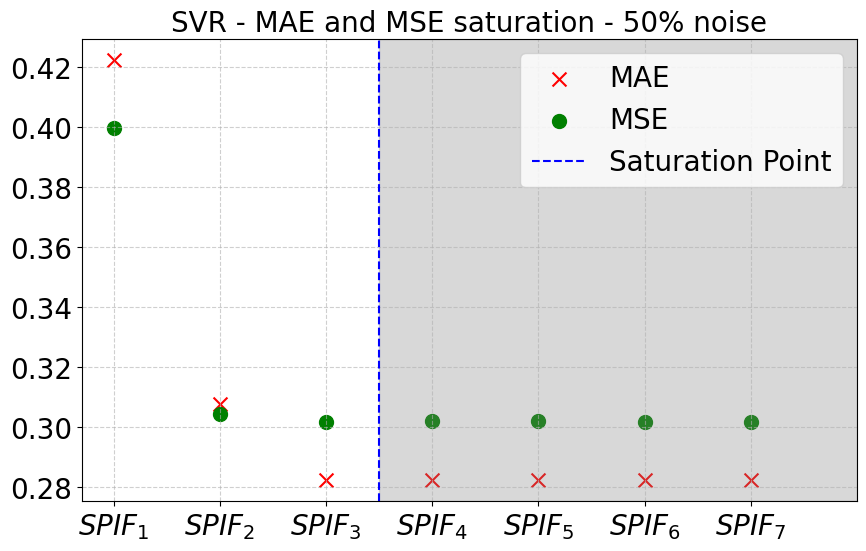

In [12]:
num_features = len(added_features)
print(num_features)
print(len(mae_list))

# LaTeX-style labels for x-axis ticks
feature_labels = [f"$SPIF_{{{i+1}}}$" for i in range(num_features)]

plt.figure(figsize=(10, 6))
plt.scatter(feature_labels, mae_list, marker='x', color='r', s=100, label='MAE')
plt.scatter(feature_labels, mse_list, marker='o', color='g', s=100, label='MSE')

# Shade the saturation region
if num_features > 3:
    plt.axvline(x=2.5, color='b', linestyle='--', label='Saturation Point')
    x_lim = plt.xlim(right=7)
    plt.axvspan(2.5, x_lim[1], color='gray', alpha=0.3)

plt.title('SVR - MAE and MSE saturation - 50% noise', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=20)
plt.show()


#### Absolute Error Distribution – LinearSVR

Absolute Errors PIFs (filtered): [0.00037907117043700644, 0.005959258237141052, 0.0023393356742840155, 0.45531119529714226, 0.18949129327576686, 0.0037253592080520592, 0.08295620483233024, 0.00997507438335865, 0.00040008746759379044, 0.00018981316579114171, 0.0003896160302372387, 0.4313221711037358, 0.0011609772115748207, 0.009462738433217543, 6.681761533833264e-05, 0.00042821218182775844, 0.7036852034299357, 0.0014843320029477303, 0.021657782503976, 0.006019631168861617, 0.0008861726722970698, 0.1856062761772026, 0.0054019327023244745, 0.1551822086076901, 0.30580126397890384, 0.2568330475804141, 0.1507408223762276, 0.002372572033412901, 0.30618589051864237, 0.9686418110821422, 0.0007214336893317519, 0.011505567674148787, 0.005712398078342673, 0.5764585009104257, 0.6091277891494289, 0.010347193506099583, 0.9156372748261308, 0.0011227638142619067, 0.0031393890862808638, 0.0011230595225572015, 0.00026228120071314365, 0.0006192156459580156, 0.0019214151758428777, 0.2841174970621997, 0.208

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_23051/4234433474.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)


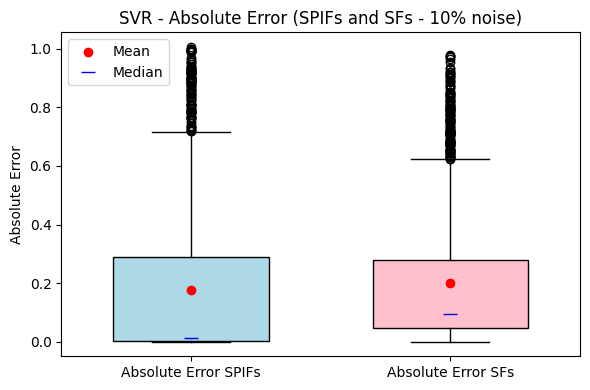

In [13]:
# --- Absolute error comparison: SPIFs vs SFs (LinearSVR) ---
absolute_errors_op = []
for true_value, predicted_value in zip(Y_test_op_scaled, Y_pred_op):
    error = abs(true_value - predicted_value)
    absolute_errors_op.append(error)

absolute_errors_feat = []
for true_value, predicted_value in zip(Y_test_feat_scaled, Y_pred_feat):
    error = abs(true_value - predicted_value)
    absolute_errors_feat.append(error)

# Remove outliers using the IQR rule
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

absolute_errors_op   = remove_outliers(absolute_errors_op)
absolute_errors_feat = remove_outliers(absolute_errors_feat)

print("Absolute Errors PIFs (filtered):", absolute_errors_op)
print("Absolute Errors SFs (filtered):", absolute_errors_feat)

colors = {'op': 'lightblue', 'feat': 'pink'}

def create_boxplot(data, labels, title):
    plt.figure(figsize=(6, 4))
    box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)

    for patch, label in zip(box['boxes'], labels):
        if 'SPIFs' in label:
            patch.set_facecolor(colors['op'])
        else:
            patch.set_facecolor(colors['feat'])

    for median in box['medians']:
        median.set_visible(False)

    means   = [np.mean(d) for d in data]
    medians = [np.median(d) for d in data]

    plt.scatter(range(1, len(labels) + 1), means,   marker='o', color='red',  zorder=3, label='Mean')
    plt.plot(   range(1, len(labels) + 1), medians, marker='_', color='blue', markersize=10,
                linestyle='None', zorder=4, label='Median')

    plt.title(title)
    plt.ylabel('Absolute Error')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

data   = [absolute_errors_op, absolute_errors_feat]
labels = ['Absolute Error SPIFs', 'Absolute Error SFs']

create_boxplot(data, labels, 'SVR - Absolute Error (SPIFs and SFs - 10% noise)')


#### Squared Error Distribution – LinearSVR

Squared Errors SPIFs (filtered): [1.4369495225648198e-07, 3.551275873693348e-05, 5.472491396977849e-06, 0.20730828456291242, 0.03590695022732269, 1.3878301229018266e-05, 0.00688173192018353, 9.950210895353796e-05, 1.6006998172561232e-07, 3.602903790765545e-08, 1.5180065101782488e-07, 0.1860388152856403, 1.347868085796046e-06, 8.954341865549241e-05, 4.4645937195013844e-09, 1.8336567266568926e-07, 2.203241494974821e-06, 0.00046905954298952896, 3.6235959409130274e-05, 7.853020051261298e-07, 0.03444968975636801, 2.91808769204426e-05, 0.02408151786836065, 0.09351441305109523, 0.06596321432944324, 0.0227227955306614, 5.629098053733027e-06, 0.09374979955269405, 5.204665681028227e-07, 0.00013237808750441753, 3.2631491805453065e-05, 0.3323044032718953, 0.3710366635140711, 0.00010706441345266939, 1.2605985826159454e-06, 9.855763835059396e-06, 1.2612626912064094e-06, 6.879142824752835e-08, 3.834280161992025e-07, 3.6918362779593166e-06, 0.08072275213688905, 0.043487069898599524, 9.621505317240288e

/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_23051/73769948.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)


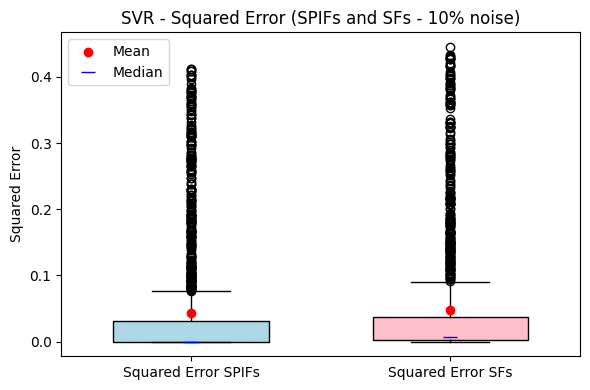

In [14]:
# --- Squared error comparison: SPIFs vs SFs (LinearSVR) ---
squared_errors_op = []
for true_value, predicted_value in zip(Y_test_op_scaled, Y_pred_op):
    error = (true_value - predicted_value)**2
    squared_errors_op.append(error)

squared_errors_feat = []
for true_value, predicted_value in zip(Y_test_feat_scaled, Y_pred_feat):
    error = (true_value - predicted_value)**2
    squared_errors_feat.append(error)

# Remove outliers using the IQR rule
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

squared_errors_op   = remove_outliers(squared_errors_op)
squared_errors_feat = remove_outliers(squared_errors_feat)

print("Squared Errors SPIFs (filtered):", squared_errors_op)
print("Squared Errors SFs (filtered):", squared_errors_feat)

colors = {'op': 'lightblue', 'feat': 'pink'}

def create_boxplot(data, labels, title):
    plt.figure(figsize=(6, 4))
    box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)

    for patch, label in zip(box['boxes'], labels):
        if 'PIFs' in label:
            patch.set_facecolor(colors['op'])
        else:
            patch.set_facecolor(colors['feat'])

    for median in box['medians']:
        median.set_visible(False)

    means   = [np.mean(d) for d in data]
    medians = [np.median(d) for d in data]

    plt.scatter(range(1, len(labels) + 1), means,   marker='o', color='red',  zorder=3, label='Mean')
    plt.plot(   range(1, len(labels) + 1), medians, marker='_', color='blue', markersize=10,
                linestyle='None', zorder=4, label='Median')

    plt.title(title)
    plt.ylabel('Squared Error')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

data   = [squared_errors_op, squared_errors_feat]
labels = ['Squared Error SPIFs', 'Squared Error SFs']

create_boxplot(data, labels, 'SVR - Squared Error (SPIFs and SFs - 10% noise)')
